# Sample MolJSON with the Anthropic API

This notebook shows a minimal example of requesting a MolJSON from the Anthropic Messages API by using the MolJSON schema. 

## Prerequisites

- Install the Anthropic Python SDK: `pip install anthropic`
- Set `ANTHROPIC_API_KEY` in your environment
- Install the MolJSON package locally with `pip install -e .`

In [1]:
import json

from IPython.display import display
from anthropic import Anthropic
from rdkit import Chem
from rdkit.Chem import Draw

from moljson import GetSchema, MolFromJSON


def extract_content_by_type(resp, block_type):
    parts = []
    content = getattr(resp, "content", None)
    if not isinstance(content, list):
        return ""
    for block in content:
        if getattr(block, "type", None) != block_type:
            continue
        text = getattr(block, block_type, None)
        if isinstance(text, str):
            parts.append(text)
    return "\n".join(parts).strip()


def extract_text_content(resp):
    return extract_content_by_type(resp, "text")


def extract_thinking_content(resp):
    return extract_content_by_type(resp, "thinking")


In [2]:
MODEL = "claude-haiku-4-5-20251001"
THINKING_BUDGET_TOKENS = 4096
MAX_TOKENS = 16384
SMILES = "CCO"

schema = GetSchema()
client = Anthropic()

prompt = f"""Convert the molecule from SMILES to MolJSON.
Return MolJSON only.
SMILES: {SMILES}
"""

print(f"Model: {MODEL}")
print(f"Thinking budget tokens: {THINKING_BUDGET_TOKENS}")
print(f"Max tokens: {MAX_TOKENS}")
print(f"SMILES: {SMILES}")
print("Top-level schema keys:", list(schema["properties"].keys()))

Model: claude-haiku-4-5-20251001
Thinking budget tokens: 4096
Max tokens: 16384
SMILES: CCO
Top-level schema keys: ['atoms', 'bonds', 'charges', 'aromatic_n_h']


## Request MolJSON from the API

In [3]:
response = client.messages.create(
    model=MODEL,
    max_tokens=MAX_TOKENS,
    messages=[{"role": "user", "content": prompt}],
    thinking={"type": "enabled", "budget_tokens": THINKING_BUDGET_TOKENS},
    output_config={
        "format": {
            "type": "json_schema",
            "schema": schema, # This gives the MolJSON schema to Anthropic API
        },
    },
)

thinking_text = extract_thinking_content(response)
raw_text = extract_text_content(response)
moljson = json.loads(raw_text)

print("Thinking process:\n")
print(thinking_text)
print("\nAnswer:\n")
print(json.dumps(moljson, indent=2))


Thinking process:

The SMILES string "CCO" represents ethanol. Let me break it down:
- C: Carbon atom
- C: Another carbon atom
- O: Oxygen atom
- Implicit bonds: Single bonds between C-C and C-O

So the structure is: CH3-CH2-OH

Now I need to convert this to MolJSON format:

1. Atoms:
   - Atom 1: C (id: "C1")
   - Atom 2: C (id: "C2")
   - Atom 3: O (id: "O3")

2. Bonds:
   - C1-C2: single bond (order 1)
   - C2-O3: single bond (order 1)

3. Charges: No charges in ethanol, so null

4. Aromatic_n_h: No aromatic nitrogens, so null

Let me structure this properly:

```json
{
  "atoms": [
    {"id": "C1", "element": "C"},
    {"id": "C2", "element": "C"},
    {"id": "O3", "element": "O"}
  ],
  "bonds": [
    {"source": "C1", "target": "C2", "order": 1},
    {"source": "C2", "target": "O3", "order": 1}
  ],
  "charges": null,
  "aromatic_n_h": null
}
```

This is valid JSON that matches the schema.

Answer:

{
  "atoms": [
    {
      "id": "C1",
      "element": "C"
    },
    {
      "i

## Convert the returned MolJSON back to an RDKit molecule

Canonical SMILES from returned MolJSON: CCO


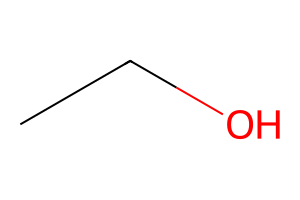

In [4]:
mol = MolFromJSON(moljson)
canonical_smiles = Chem.MolToSmiles(mol)

print("Canonical SMILES from returned MolJSON:", canonical_smiles)
display(Draw.MolToImage(mol, size=(300, 200)))
